# <span style="color:brown">Fraud Detection Pipeline using Supervised Machine Learning</span>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## <span style="color:green">1. Data Understanding and Exploratory Data Analysis (EDA)</span>

In [4]:
data = pd.read_csv("PaySim_Fraud.csv")
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,250,CASH_OUT,281200.68,C1911318394,0.0,0.0,C2013875267,1127597.36,1408798.04,0,0
1,378,CASH_OUT,150691.59,C613536510,220.0,0.0,C1480547290,1291956.94,1442648.54,0,0
2,393,PAYMENT,16114.01,C1830901026,1340.0,0.0,M892977060,0.00,0.00,0,0
3,40,CASH_OUT,96210.00,C757735777,0.0,0.0,C534617900,1227907.98,1324117.98,0,0
4,350,CASH_OUT,87415.46,C1521110897,0.0,0.0,C863909301,3077418.24,3164833.70,0,0


In [5]:
print("Dataset Shape:", data.shape)
data.info()

Dataset Shape: (200000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   type            200000 non-null  object 
 2   amount          200000 non-null  float64
 3   nameOrig        200000 non-null  object 
 4   oldbalanceOrg   200000 non-null  float64
 5   newbalanceOrig  200000 non-null  float64
 6   nameDest        200000 non-null  object 
 7   oldbalanceDest  200000 non-null  float64
 8   newbalanceDest  200000 non-null  float64
 9   isFraud         200000 non-null  int64  
 10  isFlaggedFraud  200000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 16.8+ MB


In [6]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,200000.000000,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,200000.000000,200000.000000
mean,243.683075,1.819372e+05,8.279730e+05,8.490931e+05,1.108693e+06,1.234842e+06,0.001290,0.000005
std,142.638942,6.213625e+05,2.874161e+06,2.908906e+06,3.492384e+06,3.769055e+06,0.035893,0.002236
min,1.000000,4.100000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,155.000000,1.335379e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,241.000000,7.503301e+04,1.357408e+04,0.000000e+00,1.316669e+05,2.143064e+05,0.000000,0.000000
75%,335.000000,2.093096e+05,1.066192e+05,1.425862e+05,9.520224e+05,1.118270e+06,0.000000,0.000000
max,741.000000,6.988673e+07,5.731626e+07,4.731626e+07,3.114049e+08,3.114929e+08,1.000000,1.000000


In [7]:
# Check missing values
missing_values = data.isnull().sum()
missing_values

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
# Check duplicate rows
duplicates = data.duplicated().sum()
duplicates

np.int64(0)

In [9]:
# Target Class distribution
data["isFraud"].value_counts()

isFraud
0    199742
1       258
Name: count, dtype: int64

In [10]:
data["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.871
1     0.129
Name: proportion, dtype: float64

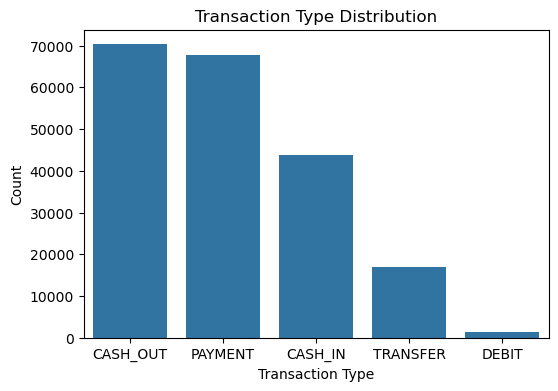

In [11]:
# Analyze Transaction Types

# Count of each transaction type
data["type"].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x="type", data=data)
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

In [12]:
# Analyze Fraud Distribution by Transaction Type (in percentage)
fraud_type = pd.crosstab(data["type"],data["isFraud"],normalize="index") * 100
fraud_type

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.819299,0.180701
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.225539,0.774461


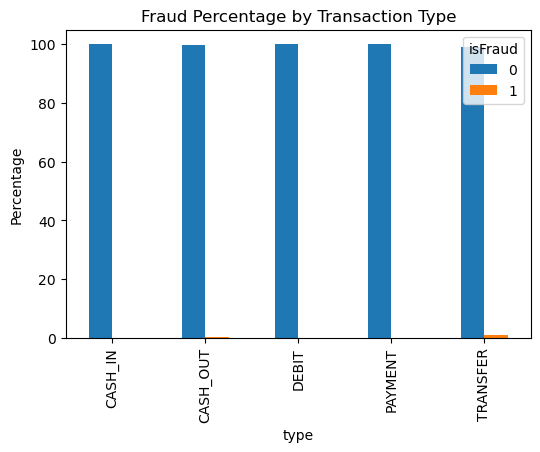

In [13]:
fraud_type.plot(kind="bar", figsize=(6,4))
plt.title("Fraud Percentage by Transaction Type")
plt.ylabel("Percentage")
plt.show()

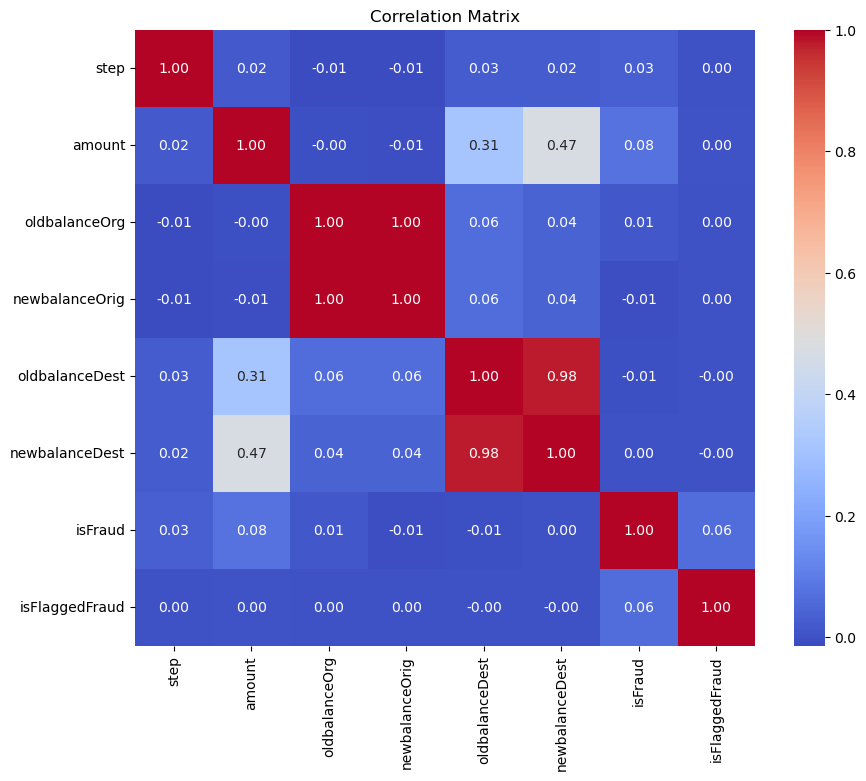

In [14]:
# Correlation MAtrix
numeric_data = data.select_dtypes(include=["number"])
correlation = numeric_data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [15]:
data["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    199999
1         1
Name: count, dtype: int64

## <span style="color:green">2. Data Preprocessing</span>

In [16]:
# Drop unnecessary columns
data = data.drop(columns=[
    "nameOrig",
    "nameDest",
    "isFlaggedFraud"
])

# Display remaining columns
data.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [17]:
# Apply One-Hot Encoding
data = pd.get_dummies(
    data,
    columns=["type"],
    drop_first=True,
    dtype=int
)
data.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,250,281200.68,0.0,0.0,1127597.36,1408798.04,0,1,0,0,0
1,378,150691.59,220.0,0.0,1291956.94,1442648.54,0,1,0,0,0
2,393,16114.01,1340.0,0.0,0.00,0.00,0,0,0,1,0
3,40,96210.00,0.0,0.0,1227907.98,1324117.98,0,1,0,0,0
4,350,87415.46,0.0,0.0,3077418.24,3164833.70,0,1,0,0,0


In [18]:
# Separate features and target variable

X = data.drop("isFraud", axis=1)
y = data["isFraud"]
print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (200000, 10)
Target Vector Shape: (200000,)


## <span style="color:green">3. Train Test Split</span>

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (160000, 10)
Testing Set: (40000, 10)


In [20]:
print("Training Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Target Distribution:
isFraud
0    159794
1       206
Name: count, dtype: int64

Testing Target Distribution:
isFraud
0    39948
1       52
Name: count, dtype: int64


## <span style="color:green">4. Handling Class Imbalance Using SMOTE</span>

In [21]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on the training dataset
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [22]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
isFraud
0    159794
1       206
Name: count, dtype: int64

After SMOTE:
isFraud
0    159794
1    159794
Name: count, dtype: int64


## <span style="color:green">5. Feature Scaling</span>

In [23]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale only the training data after SMOTE
X_train_scaled = scaler.fit_transform(X_train_smote)

# Scale the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [24]:
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_smote: (319588, 10)
y_train_smote: (319588,)
X_train_scaled: (319588, 10)
X_test_scaled: (40000, 10)


## <span style="color:green">6. Model Building</span>

## <span style="color:red">Logistic Regression</span>

In [25]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
# Predictions on test data
y_pred_lr = lr_model.predict(X_test_scaled)

# Prediction probabilities for ROC-AUC
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [28]:
print("Logistic Regression Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Performance:
Accuracy : 0.960625
Precision: 0.02964793082149475
Recall   : 0.9230769230769231
F1-Score : 0.05745062836624776
ROC-AUC  : 0.9739724141383799


In [29]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     39948
           1       0.03      0.92      0.06        52

    accuracy                           0.96     40000
   macro avg       0.51      0.94      0.52     40000
weighted avg       1.00      0.96      0.98     40000



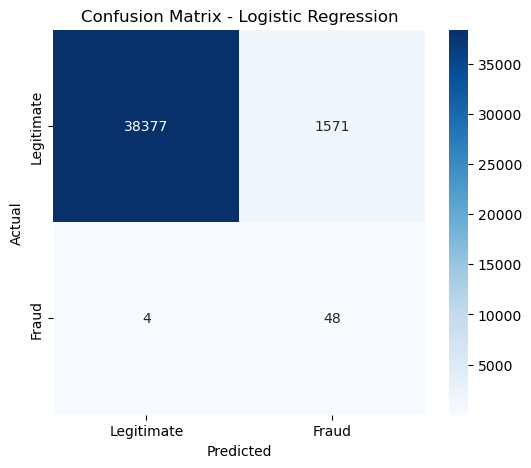

In [30]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## <span style="color:red">Random Forest</span>

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
# Predict class labels
y_pred_rf = rf_model.predict(X_test)

# Predict probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [33]:
print("Random Forest Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Random Forest Performance
Accuracy : 0.999125
Precision: 0.6349206349206349
Recall   : 0.7692307692307693
F1-Score : 0.6956521739130435
ROC-AUC  : 0.998823229814143


In [34]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39948
           1       0.63      0.77      0.70        52

    accuracy                           1.00     40000
   macro avg       0.82      0.88      0.85     40000
weighted avg       1.00      1.00      1.00     40000



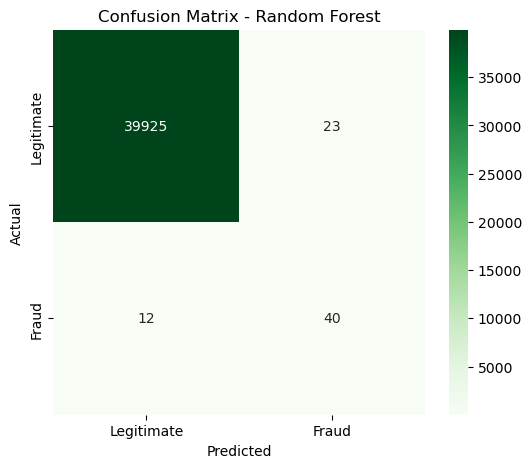

In [35]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## <span style="color:green">7. Hyperparameter Tuning</span>

### <span style="color:red"> Hyperparameter Tuning - Logistic Regression</span>

In [36]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

# Initialize GridSearchCV
grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_lr,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Train
grid_lr.fit(X_train_scaled, y_train_smote)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [37]:
# Best Logistic Regression Model
print("Best Parameters:")
print(grid_lr.best_params_)
best_lr = grid_lr.best_estimator_

Best Parameters:
{'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}


In [38]:
# Evaluate Tuned Logistic Regression
y_pred_best_lr = best_lr.predict(X_test_scaled)
y_prob_best_lr = best_lr.predict_proba(X_test_scaled)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_best_lr))
print("Precision:", precision_score(y_test, y_pred_best_lr))
print("Recall   :", recall_score(y_test, y_pred_best_lr))
print("F1 Score :", f1_score(y_test, y_pred_best_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best_lr))

Accuracy : 0.96595
Precision: 0.03480113636363636
Recall   : 0.9423076923076923
F1 Score : 0.06712328767123288
ROC AUC  : 0.9758440780707227


### <span style="color:red"> Hyperparameter Tuning (Random Forest) </span>       

In [39]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [40]:
# Initialize Search
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=10,          
    scoring='f1',
    cv=3,               
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(X_train_smote, y_train_smote)


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [41]:
# Best Random Forest
print(random_search.best_params_)
best_rf = random_search.best_estimator_

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}


In [42]:
# Evaluate Tuned Random Forest
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall   :", recall_score(y_test, y_pred_best_rf))
print("F1 Score :", f1_score(y_test, y_pred_best_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best_rf))

Accuracy : 0.999075
Precision: 0.6153846153846154
Recall   : 0.7692307692307693
F1 Score : 0.6837606837606838
ROC AUC  : 0.998936598347082


## <span style="color:green"> 8. Model Comparison</span>

In [43]:
# Final Model Comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_best_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_best_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_best_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_best_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_best_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_best_rf)
    ]
})

comparison = comparison.round(4)
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9606,0.0296,0.9231,0.0575,0.9740
1,Tuned Logistic Regression,0.9660,0.0348,0.9423,0.0671,0.9758
2,Random Forest,0.9991,0.6349,0.7692,0.6957,0.9988
3,Tuned Random Forest,0.9991,0.6154,0.7692,0.6838,0.9989


# <span style="color:red">Conclusion</span>

<span style="color:navy">

- Logistic Regression and Random Forest were evaluated using __Precision, Recall, F1-score, and ROC-AUC__, as these metrics are more suitable than accuracy for imbalanced datasets.
- Logistic Regression achieved high recall but very low precision, resulting in many false positive predictions.
- Random Forest provided the best balance between Precision, Recall, F1-score, and ROC-AUC, making it the most effective model for fraud detection.
- Although hyperparameter tuning of Random Forest slightly improved the ROC-AUC score, but the __default Random Forest__ achieved a higher Precision and F1-score than the tuned model.
- Therefore, <span style="color:red">__Random Forest was selected as the final model__</span> because it delivered the best overall performance on the fraud detection dataset.
</span>

### <span style="color:green"> # Feature Importance (Default Random Forest)</span>

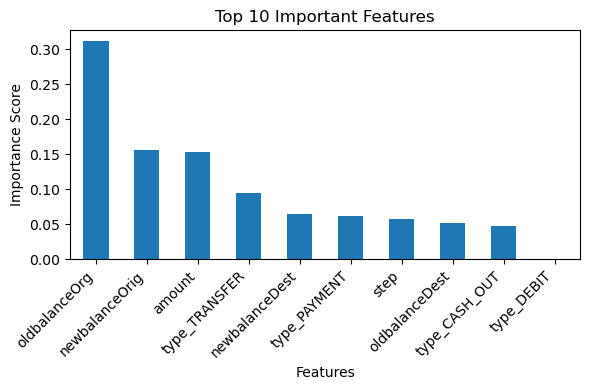

In [44]:
# Feature Importance (Default Random Forest)
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(6,4))
feature_importance.head(10).plot(kind='bar')

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()